Figure S3: Tissue specificity of clusters. A Histogram of the number of tissues a cluster is in. B Upset plot detail of which tissues a cluster is shared across for all tissue combinations with 20 or more clusters. C A tissue-specific thirty-eight gene cluster on chromosome 17 from sun exposed skin gene expression. Color is the expression Spearman correlation. D A six gene cluster on chromosome 6, shared across 6 tissues. Color is the expression Spearman correlation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import upsetplot as up
from scipy.stats import spearmanr, ttest_ind, ttest_rel, norm
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import ast
import pyranges as pr



from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *
from annotate_clusters import * 
import call_clusters



%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# load in clusters
clusters = load_across_tissues(config, load_clusters_annotated)

In [8]:
tissue_sharing = clusters.groupby('cluster_id').agg({'tissue_id':'unique'})

def get_pretty_tissue_id(tissue_id_list):
    return [tissue_id.replace('_', ' ') for tissue_id in tissue_id_list]
tissue_sharing['tissue_id_pretty'] = tissue_sharing['tissue_id'].apply(get_pretty_tissue_id)

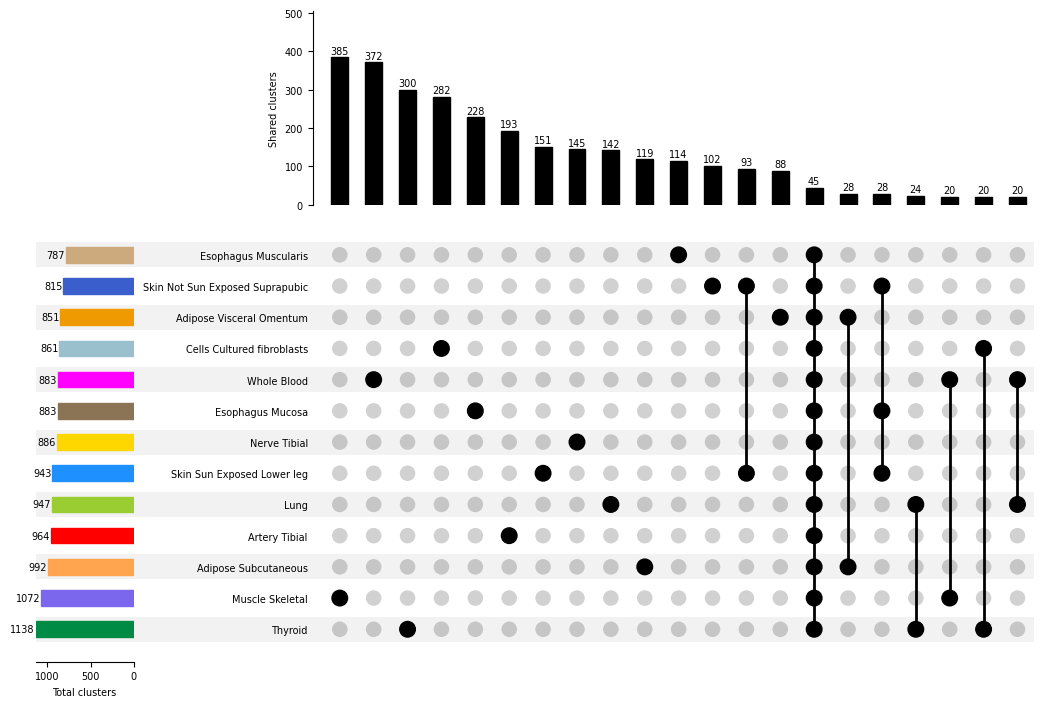

In [ ]:
upset = up.UpSet(up.from_memberships(tissue_sharing['tissue_id_pretty']), subset_size='count', min_subset_size=20, show_counts=True, 
                 sort_by="cardinality", facecolor="black", totals_plot_elements=3)


# style the instersection plot
plot_result = upset.plot()
intersection_plot = plot_result["intersections"]
intersection_plot.set_ylabel("Shared clusters")
intersection_plot.set_xlim(-.8, intersection_plot.get_xlim()[1])
intersection_plot.set_ylim(0, intersection_plot.get_ylim()[1]+100)
intersection_plot.grid(False)

# style the totals plot
totals_plot = plot_result["totals"]
#totals_plot.set_xlim((1200, 0))
totals_plot.grid(False)
totals_plot.set_xlabel("Total clusters")
# change totals plot colors to match gtex tissues
gtex_tissue_pal_df['tissue_id_pretty'] = gtex_tissue_pal_df['tissue_id'].str.replace('_', ' ')
for bar, label in zip(plot_result["totals"].patches, totals_plot.get_yticklabels()):
    bar.set_color(gtex_tissue_pal_df[gtex_tissue_pal_df['tissue_id_pretty'] == label.get_text()]['hex'].iloc[0])  # Set the color based on the palette

plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s3_b.pdf", transparent=True)
plt.show()

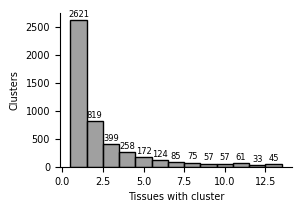

In [ ]:
tissue_sharing['num_tissues'] = tissue_sharing['tissue_id'].apply(len)
fig, ax = plt.subplots(figsize=(3, 2))
sns.histplot(tissue_sharing, x='num_tissues', discrete=True, ax=ax, color='grey')
ax.bar_label(ax.containers[0], fontsize=6, padding=1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel("Tissues with cluster")
ax.set_ylabel("Clusters")
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s3_a.pdf", transparent=True)
plt.show()

In [ ]:
def plot_cluster(example_cluster, cbar=False):
    # gene gene ids sorted by tss start
    sorted_cluster = gid_gencode.loc[example_cluster['cluster_id'].split('_')].sort_values('tss_start')
    sorted_gene_ids = sorted_cluster.index.values
    # get normed expression 
    expression = load_cluster_expression(config, example_cluster['Tissue'])
    cluster_expression = expression[(expression['cluster_id']==example_cluster['cluster_id'])].set_index('egene_id').loc[sorted_gene_ids]
    # get correlation of expression
    sample_ids = cluster_expression.columns[cluster_expression.columns.str.contains('GTEX')]
    cluster_corr, cluster_pvalue = spearmanr(cluster_expression[sample_ids], axis=1)
    # make df wtih readable gene names
    cluster_corr = pd.DataFrame(cluster_corr, index=sorted_cluster['gene_name'].values, columns=sorted_cluster['gene_name'].values)

    # make corr plot
    fig_size = int(len(cluster_corr)/4)
    print(fig_size)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    sns.heatmap(cluster_corr, mask=np.triu(np.ones_like(cluster_corr), k=1),
                cmap=corr_cmap, vmin=-1, vmax=1, ax=ax, 
                cbar_kws={'label':'Spearman Corrleation'}, 
                xticklabels=True, yticklabels=True, cbar=cbar)
    ax.tick_params("y", rotation=0) 
    return ax
     

9


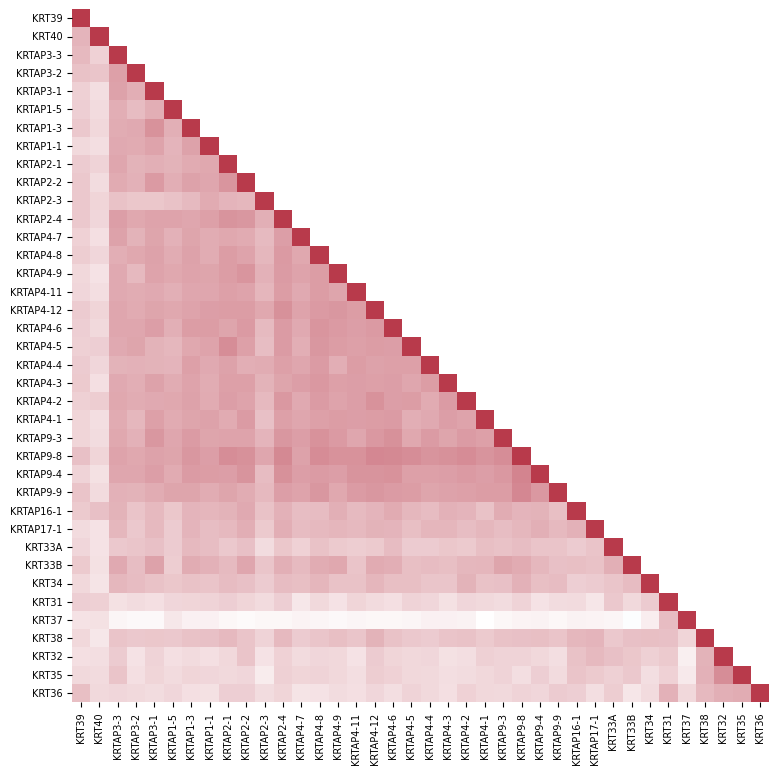

In [ ]:
# keratin cluster
plot_cluster(clusters.iloc[9757])
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s3_c.pdf", transparent=True)
plt.show()

In [ ]:
shared_cluster_id = 'ENSG00000105808.17_ENSG00000168255.19_ENSG00000170667.14_ENSG00000205238.9_ENSG00000228049.7_ENSG00000267368.1'

1


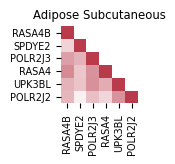

1


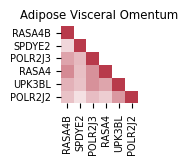

1


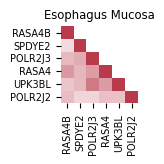

1


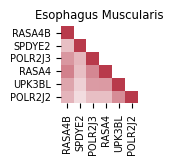

1


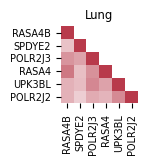

1


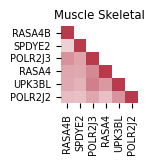

1


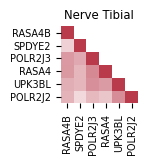

1


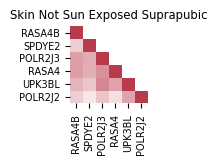

1


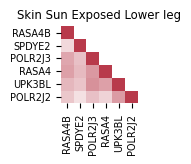

1


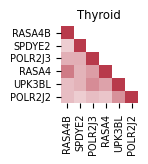

In [ ]:
for idx, cluster in clusters[clusters['cluster_id']==shared_cluster_id].iterrows():
    ax = plot_cluster(cluster)
    ax.set_title(cluster['Tissue'].replace('_', ' '))
    plt.savefig(f"/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s3_d_{cluster['tissue']}.pdf", transparent=True)
    plt.show()